In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


In [2]:
df_reduced = pd.read_csv('reduced_tuesday_bruteforce_columns_2.csv', sep = ',')
for i, col in enumerate(df_reduced.columns):
    print(i, repr(col))
print(f"\nKích thước dataset cuối cùng: {df_reduced.shape}")

0 'flow duration'
1 'flow iat mean'
2 'flow iat std'
3 'flow iat max'
4 'flow iat min'
5 'fwd iat mean'
6 'fwd iat std'
7 'total fwd packets'
8 'total backward packets'
9 'fwd packet length mean'
10 'fwd packet length std'
11 'bwd packet length mean'
12 'bwd packet length std'
13 'flow packets/s'
14 'flow bytes/s'
15 'fwd psh flags'
16 'ack flag count'
17 'syn flag count'
18 'fin flag count'
19 'init_win_bytes_forward'
20 'init_win_bytes_backward'
21 'label'

Kích thước dataset cuối cùng: (27660, 22)


In [3]:
#split X(features) and y(label)
X = df_reduced.drop('label', axis=1)
y = df_reduced['label']

#label encoding to number(BENIGN -> 0, FTP -> 1, SSH -> 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nLabel mapping: ")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")


#split train/test set (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.2,
                                                             random_state = 42, stratify = y_encoded) 


#normalization
#use MinMaxScaler to take data about [0, 1] (necessary for running IPS stably )
scaler = MinMaxScaler()

#fit train and test on train and transform
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)




Label mapping: 
BENIGN -> 0
FTP-Patator -> 1
SSH-Patator -> 2


In [4]:
#setup ensemble model (XGBOOST + RANDOM FOREST)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(eval_metric = 'mlogloss', random_state = 42)

ensemble_model = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    voting = 'soft'

)
print("--Training ... Wait a few minutes--")
ensemble_model.fit(X_train, y_train)
print("--Training completed !")



--Training ... Wait a few minutes--
--Training completed !



----Result of Ensemble Model (XGBOOST + RANDOM FOREST)---
Accuracy: 99.96%
Precision: 0.9996
Recall:    0.9996
F1-Score:  0.9996

Classification Report: 
              precision    recall  f1-score   support

      BENIGN     0.9996    0.9996    0.9996      2766
 FTP-Patator     0.9994    1.0000    0.9997      1587
 SSH-Patator     1.0000    0.9992    0.9996      1179

    accuracy                         0.9996      5532
   macro avg     0.9997    0.9996    0.9996      5532
weighted avg     0.9996    0.9996    0.9996      5532



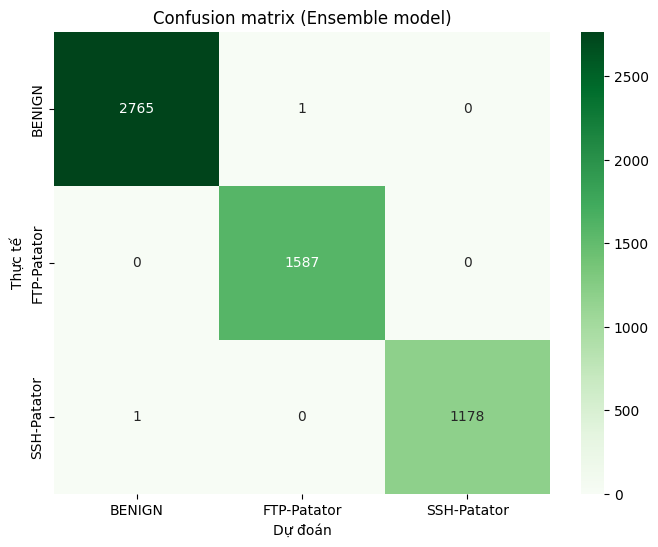


--- LƯU CÁC FILE QUAN TRỌNG ---
1. Đã lưu: ids_model.pkl (Bao gồm cả RF và XGBoost)
2. Đã lưu: ids_scaler.pkl
3. Đã lưu: ids_label_encoder.pkl


In [5]:
print("\n----Result of Ensemble Model (XGBOOST + RANDOM FOREST)---")
y_pred = ensemble_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")
# Tính toán riêng lẻ (average='weighted' để tính trung bình có trọng số cho 3 lớp)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


print("\nClassification Report: ")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (Ensemble model)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()



print("\n--- LƯU CÁC FILE QUAN TRỌNG ---")

# Lưu Ensemble Model (Nó chứa cả RF và XGB bên trong)
joblib.dump(ensemble_model, 'ids_model.pkl') 
print("1. Đã lưu: ids_model.pkl (Bao gồm cả RF và XGBoost)")

# Lưu lại Scaler và Label Encoder (không thay đổi, nhưng lưu lại cho chắc)
joblib.dump(scaler, 'ids_scaler.pkl')
print("2. Đã lưu: ids_scaler.pkl")
joblib.dump(le, 'ids_label_encoder.pkl')
print("3. Đã lưu: ids_label_encoder.pkl")

In [6]:
print("DANH SÁCH FEATURES CẦN DÙNG CHO IPS:")
print(list(X_train.columns) if hasattr(X_train, 'columns') else "Bạn hãy dùng df_reduced.drop('label', axis=1).columns")

# Hoặc nếu X_train đã là numpy array, hãy in từ df_reduced:
print(list(df_reduced.drop('label', axis=1).columns))

DANH SÁCH FEATURES CẦN DÙNG CHO IPS:
Bạn hãy dùng df_reduced.drop('label', axis=1).columns
['flow duration', 'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min', 'fwd iat mean', 'fwd iat std', 'total fwd packets', 'total backward packets', 'fwd packet length mean', 'fwd packet length std', 'bwd packet length mean', 'bwd packet length std', 'flow packets/s', 'flow bytes/s', 'fwd psh flags', 'ack flag count', 'syn flag count', 'fin flag count', 'init_win_bytes_forward', 'init_win_bytes_backward']
